In [ ]:
# ==========================================
# FINBERT SENTIMENT ANALYSIS WITH FILE PICKER
# ==========================================

!pip -q install transformers torch pandas

import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from google.colab import files
import io

# =========================
# LOAD FINBERT
# =========================

print("Loading FinBERT...")

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

model.eval()

print("✅ FinBERT Loaded")

# =========================
# UPLOAD CSV FILE
# =========================

print("\n📂 Choose your CSV file")

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\n✅ Loaded: {filename}")
print("Rows:", len(df))

# =========================
# CHECK REQUIRED COLUMN
# =========================

if "News" not in df.columns:
    raise ValueError(
        f"'News' column not found.\nAvailable columns: {list(df.columns)}"
    )

# =========================
# SENTIMENT FUNCTION
# =========================

def get_sentiment_score(text):

    if pd.isna(text):
        return 0.5

    text = str(text).strip()

    if text == "" or text == "No headlines archived for this date":
        return 0.5

    try:

        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=512
        )

        with torch.no_grad():
            outputs = model(**inputs)

        probs = F.softmax(outputs.logits, dim=1)[0]

        # FinBERT:
        # 0 = positive
        # 1 = negative
        # 2 = neutral

        positive = probs[0].item()
        neutral = probs[2].item()

        sentiment_score = positive + (0.5 * neutral)

        return round(sentiment_score, 4)

    except Exception as e:
        print("Error:", e)
        return 0.5

# =========================
# GENERATE SENTIMENT COLUMN
# =========================

print("\nGenerating sentiment scores...")

df["sentiment_score"] = df["News"].apply(get_sentiment_score)

# =========================
# SAVE RESULT
# =========================

output_file = "sentiment_output.csv"

df.to_csv(output_file, index=False)

print("\n✅ Sentiment analysis completed!")

print("\nPreview:")
display(df[["News", "sentiment_score"]].head())

# =========================
# DOWNLOAD RESULT
# =========================

files.download(output_file)

print(f"\n✅ Downloading: {output_file}")

Loading FinBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Saving TSLA_with_sentiment (2).csv to TSLA_with_sentiment (2).csv

✅ Loaded: TSLA_with_sentiment (2).csv
Rows: 450

Generating sentiment scores...

✅ Sentiment analysis completed!

Preview:


,News,sentiment_score
0,"Tesla: TSLA sheds more weight afterhours, drop...",0.1125
1,No headlines archived for this date,0.5000
2,Tesla’s Tumble: Why TSLA Stock Could Fall to $...,0.2584
3,No headlines archived for this date,0.5000
4,Tesla (TSLA) Technical Analysis: Potential Reb...,0.3057


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloading: sentiment_output.csv


In [ ]:
# ==========================================
# MARKET DIRECTION FROM SENTIMENT CSV
# ==========================================

import pandas as pd
from google.colab import files
import io

# =========================
# UPLOAD CSV
# =========================

print("Upload CSV containing sentiment_score column")

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\nLoaded: {filename}")
print("Rows:", len(df))

# =========================
# CHECK COLUMN
# =========================

if "sentiment_score" not in df.columns:
    raise ValueError(
        f"'sentiment_score' column not found.\nAvailable columns: {list(df.columns)}"
    )

# =========================
# LAST DAY + LAST 3 DAYS
# =========================

last_day_sentiment = df["sentiment_score"].iloc[-1]

last_3_day_sentiment = (
    df["sentiment_score"]
    .tail(3)
    .sum()
)

# =========================
# FINAL PREDICTION
# =========================

if (
    last_day_sentiment > 0.51
    or
    last_3_day_sentiment > 1.53
):
    prediction = 1
    direction = "UP"
else:
    prediction = 0
    direction = "DOWN"

# =========================
# ROW-WISE SIGNALS
# =========================

df["last3_sentiment_sum"] = (
    df["sentiment_score"]
    .rolling(window=3, min_periods=1)
    .sum()
)

df["market_signal"] = (
    (df["sentiment_score"] > 0.50)
    |
    (df["last3_sentiment_sum"] > 1.50)
).astype(int)

df["market_direction"] = df["market_signal"].map(
    {
        1: "UP",
        0: "DOWN"
    }
)

# =========================
# DISPLAY RESULT
# =========================

print("\n==============================")
print("LAST DAY SENTIMENT :", round(last_day_sentiment, 4))
print("LAST 3 DAYS SUM    :", round(last_3_day_sentiment, 4))
print("PREDICTION         :", prediction)
print("DIRECTION          :", direction)
print("==============================")

# =========================
# SAVE CSV
# =========================

output_file = "market_prediction_output.csv"

df.to_csv(output_file, index=False)

print(f"\nSaved: {output_file}")

# Preview
display(df.tail())

# =========================
# DOWNLOAD
# =========================

files.download(output_file)

Upload CSV containing sentiment_score column


Saving sentiment_output (1).csv to sentiment_output (1) (1).csv

Loaded: sentiment_output (1) (1).csv
Rows: 450

LAST DAY SENTIMENT : 0.5064
LAST 3 DAYS SUM    : 1.5051
PREDICTION         : 0
DIRECTION          : DOWN

Saved: market_prediction_output.csv


,Date,Open,High,Low,Close,Volume,News,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,sentiment_score,last3_sentiment_sum,market_signal,market_direction
445,12/19/2025,488.119995,490.489990,474.720001,481.200012,103305400,TSLA Stock Price Prediction: Where Tesla Could...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5590,1.6568,1,UP
446,12/22/2025,489.880005,498.829987,485.329987,488.730011,86916100,Why Tesla (TSLA) Stock Is Trading Up Today,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5799,1.7188,1,UP
447,12/23/2025,489.399994,491.970001,482.839996,485.559998,58223600,Tesla Stock (TSLA) Opinions on Cybertruck Pric...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5355,1.6744,1,UP
448,12/24/2025,488.480011,490.899994,476.799988,485.399994,41285400,Cathie Wood Reduced Her Stake in Tesla: Is TSL...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.4632,1.5786,1,UP
449,12/26/2025,485.230011,489.089996,473.820007,475.190002,58780700,"Tesla, Inc. (TSLA) Is a Trending Stock: Facts ...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5064,1.5051,1,UP


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Preparing metadata (setup.py) ... done
Upload Stock CSV File


Saving TSLA_with_sentiment (2).csv to TSLA_with_sentiment (2) (1).csv

Loaded File: TSLA_with_sentiment (2) (1).csv
Generating Indicators...

Training XGBoost Model...

MODEL PERFORMANCE
Accuracy: 96.25%

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        39
           1       0.97      0.95      0.96        41

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80



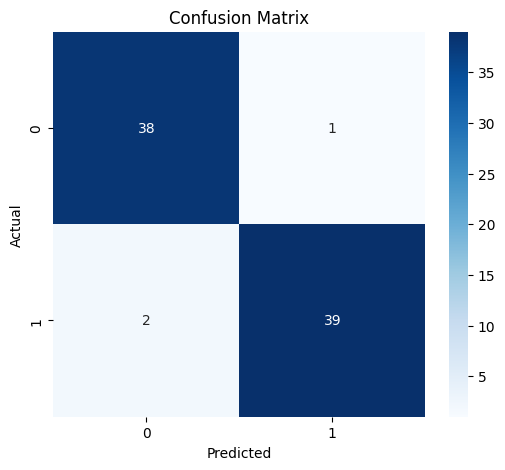

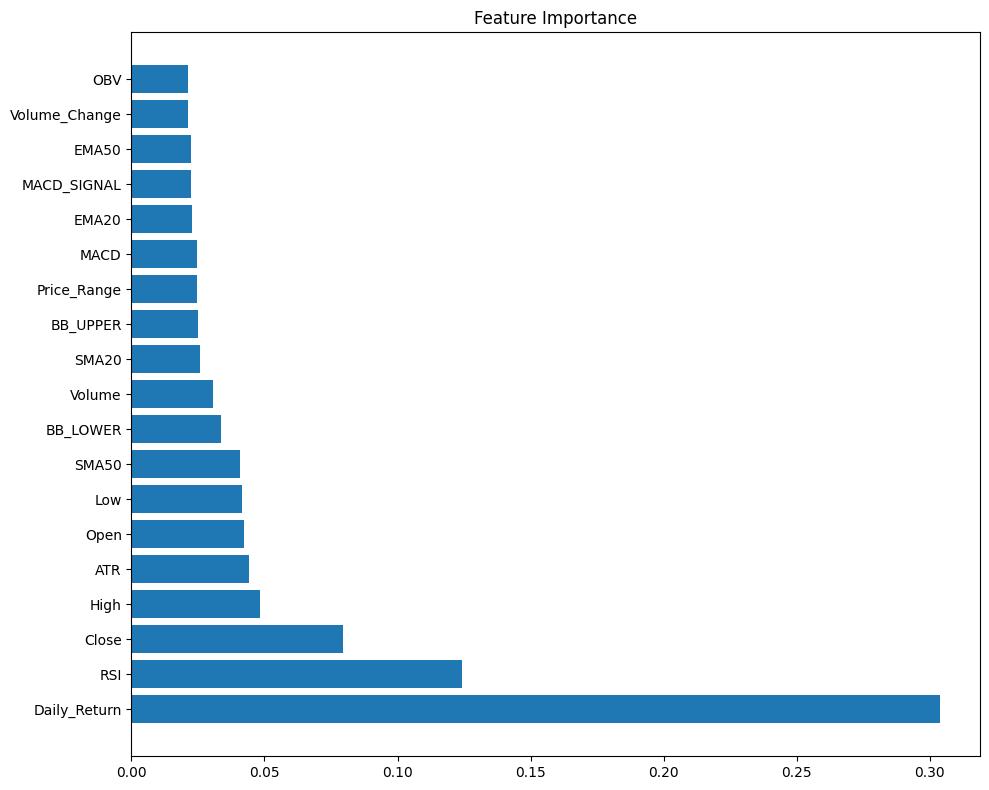


NEXT DAY FORECAST
Prediction : UP
Probability UP : 98.14%
Probability DOWN : 1.86%

Saved: stock_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done Successfully.


In [ ]:
# ==========================================
# STOCK DIRECTION PREDICTION USING XGBOOST
# SINGLE GOOGLE COLAB CELL
# ==========================================

!pip -q install ta xgboost joblib

import pandas as pd
import numpy as np
import ta
import io
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ==========================================
# UPLOAD CSV
# ==========================================

print("Upload Stock CSV File")
uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\nLoaded File: {filename}")

# ==========================================
# BASIC CLEANING
# ==========================================

df.columns = [c.strip() for c in df.columns]

required_cols = ['Open','High','Low','Close','Volume']

for col in required_cols:
    if col not in df.columns:
        raise Exception(f"Missing column: {col}")

if 'Date' in df.columns:
    df = df.sort_values('Date')

df = df.dropna(axis=1, how='all')

# ==========================================
# TECHNICAL INDICATORS
# ==========================================

print("Generating Indicators...")

df['RSI'] = ta.momentum.RSIIndicator(
    close=df['Close'],
    window=14
).rsi()

df['SMA20'] = ta.trend.sma_indicator(
    close=df['Close'],
    window=20
)

df['SMA50'] = ta.trend.sma_indicator(
    close=df['Close'],
    window=50
)

df['EMA20'] = ta.trend.ema_indicator(
    close=df['Close'],
    window=20
)

df['EMA50'] = ta.trend.ema_indicator(
    close=df['Close'],
    window=50
)

macd = ta.trend.MACD(close=df['Close'])

df['MACD'] = macd.macd()
df['MACD_SIGNAL'] = macd.macd_signal()

bb = ta.volatility.BollingerBands(
    close=df['Close']
)

df['BB_UPPER'] = bb.bollinger_hband()
df['BB_LOWER'] = bb.bollinger_lband()

df['ATR'] = ta.volatility.AverageTrueRange(
    high=df['High'],
    low=df['Low'],
    close=df['Close']
).average_true_range()

df['OBV'] = ta.volume.OnBalanceVolumeIndicator(
    close=df['Close'],
    volume=df['Volume']
).on_balance_volume()

# ==========================================
# EXTRA FEATURES
# ==========================================

df['Daily_Return'] = df['Close'].pct_change()

df['Price_Range'] = (
    df['High'] - df['Low']
)

df['Volume_Change'] = (
    df['Volume'].pct_change()
)

# ==========================================
# TARGET CREATION
# ==========================================

df['Tomorrow_Close'] = df['Close'].shift(-1)

df['Target'] = (
    df['Tomorrow_Close'] > df['Close']
).astype(int)

# ==========================================
# REMOVE NaN
# ==========================================

df.dropna(inplace=True)

# ==========================================
# FEATURES
# ==========================================

features = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'RSI',
    'SMA20',
    'SMA50',
    'EMA20',
    'EMA50',
    'MACD',
    'MACD_SIGNAL',
    'BB_UPPER',
    'BB_LOWER',
    'ATR',
    'OBV',
    'Daily_Return',
    'Price_Range',
    'Volume_Change'
]

X = df[features]
y = df['Target']

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# ==========================================
# MODEL
# ==========================================

print("\nTraining XGBoost Model...")

model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=8,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# TEST PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n========================")
print("MODEL PERFORMANCE")
print("========================")

print(
    f"Accuracy: {accuracy*100:.2f}%"
)

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred
    )
)

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# ==========================================
# PREDICT ENTIRE DATASET
# ==========================================

df['Prediction'] = model.predict(X)

df['Probability_Up'] = (
    model.predict_proba(X)[:,1]
)

df['Signal'] = np.where(
    df['Prediction']==1,
    'UP',
    'DOWN'
)

# ==========================================
# NEXT DAY FORECAST
# ==========================================

latest_data = X.iloc[[-1]]

next_day_pred = model.predict(
    latest_data
)[0]

next_day_prob = model.predict_proba(
    latest_data
)[0][1]

print("\n========================")
print("NEXT DAY FORECAST")
print("========================")

if next_day_pred == 1:
    print("Prediction : UP")
else:
    print("Prediction : DOWN")

print(
    f"Probability UP : {next_day_prob*100:.2f}%"
)

print(
    f"Probability DOWN : {(1-next_day_prob)*100:.2f}%"
)

# ==========================================
# SAVE MODEL
# ==========================================

joblib.dump(
    model,
    "stock_xgb_model.pkl"
)

# ==========================================
# SAVE CSV
# ==========================================

output_file = "stock_predictions.csv"

df.to_csv(
    output_file,
    index=False
)

print(
    f"\nSaved: {output_file}"
)

files.download(output_file)

print("\nDone Successfully.")

In [ ]:
# ==========================================
# ENSEMBLE ACCURACY CALCULATION
# Sentiment + Technical Analysis
# ==========================================

import pandas as pd
import numpy as np
import io
from google.colab import files
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Upload market_prediction_output.csv")
uploaded1 = files.upload()

print("\nUpload stock_predictions.csv")
uploaded2 = files.upload()

# ------------------------------------------
# LOAD FILES
# ------------------------------------------

file1 = next(iter(uploaded1))
file2 = next(iter(uploaded2))

sentiment_df = pd.read_csv(io.BytesIO(uploaded1[file1]))
technical_df = pd.read_csv(io.BytesIO(uploaded2[file2]))

print("\nFiles Loaded Successfully")

# ------------------------------------------
# DATE CLEANING
# ------------------------------------------

sentiment_df['Date'] = pd.to_datetime(
    sentiment_df['Date'],
    errors='coerce',
    dayfirst=True
)

technical_df['Date'] = pd.to_datetime(
    technical_df['Date'],
    errors='coerce',
    dayfirst=True
)

# ------------------------------------------
# SENTIMENT SIGNAL -> BINARY
# ------------------------------------------

if 'market_signal' in sentiment_df.columns:
    sentiment_df['Sentiment_Prediction'] = (
        sentiment_df['market_signal']
    ).astype(int)

elif 'market_direction' in sentiment_df.columns:

    sentiment_df['Sentiment_Prediction'] = np.where(
        sentiment_df['market_direction'].str.upper()=='UP',
        1,
        0
    )

else:
    raise Exception(
        "No market_signal or market_direction column found."
    )

# ------------------------------------------
# TECHNICAL SIGNAL
# ------------------------------------------

if 'Prediction' not in technical_df.columns:
    raise Exception(
        "Prediction column not found in stock_predictions.csv"
    )

technical_df['Technical_Prediction'] = (
    technical_df['Prediction']
).astype(int)

# ------------------------------------------
# MERGE ON DATE
# ------------------------------------------

merged = pd.merge(
    technical_df,
    sentiment_df[['Date','Sentiment_Prediction']],
    on='Date',
    how='inner'
)

print("\nMatched Rows:", len(merged))

# ------------------------------------------
# AND OPERATION
# ------------------------------------------

merged['Final_Prediction'] = np.where(
    (merged['Technical_Prediction']==1) &
    (merged['Sentiment_Prediction']==1),
    1,
    0
)

# ------------------------------------------
# ACTUAL MARKET MOVEMENT
# ------------------------------------------

# Tomorrow_Close - Close

merged['Price_Difference'] = (
    merged['Tomorrow_Close'] -
    merged['Close']
)

merged['Actual_Movement'] = np.where(
    merged['Price_Difference'] > 0,
    1,
    0
)

# ------------------------------------------
# ACCURACY
# ------------------------------------------

accuracy = accuracy_score(
    merged['Actual_Movement'],
    merged['Final_Prediction']
)

print("\n================================")
print("FINAL ENSEMBLE ACCURACY")
print("================================")

print(
    f"Accuracy : {accuracy*100:.2f}%"
)

print("\nClassification Report:\n")

print(
    classification_report(
        merged['Actual_Movement'],
        merged['Final_Prediction']
    )
)

# ------------------------------------------
# SAVE RESULTS
# ------------------------------------------

output_cols = [
    'Date',
    'Close',
    'Tomorrow_Close',
    'Price_Difference',
    'Actual_Movement',
    'Technical_Prediction',
    'Sentiment_Prediction',
    'Final_Prediction'
]

output_file = "ensemble_predictions.csv"

merged[output_cols].to_csv(
    output_file,
    index=False
)

print(
    f"\nSaved: {output_file}"
)

files.download(output_file)

# ------------------------------------------
# SUMMARY
# ------------------------------------------

print("\nPrediction Counts")

print(
    merged['Final_Prediction']
    .value_counts()
)

print("\nActual Counts")

print(
    merged['Actual_Movement']
    .value_counts()
)

print("\nDone.")

Upload market_prediction_output.csv


Saving market_prediction_output (1).csv to market_prediction_output (1).csv

Upload stock_predictions.csv


Saving stock_predictions (1).csv to stock_predictions (1).csv

Files Loaded Successfully

Matched Rows: 400

FINAL ENSEMBLE ACCURACY
Accuracy : 72.50%

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.99      0.79       206
           1       0.98      0.44      0.61       194

    accuracy                           0.72       400
   macro avg       0.82      0.72      0.70       400
weighted avg       0.81      0.72      0.70       400


Saved: ensemble_predictions.csv


/tmp/ipykernel_1570/1174447020.py:34: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  sentiment_df['Date'] = pd.to_datetime(
/tmp/ipykernel_1570/1174447020.py:40: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  technical_df['Date'] = pd.to_datetime(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Prediction Counts
Final_Prediction
0    312
1     88
Name: count, dtype: int64

Actual Counts
Actual_Movement
0    206
1    194
Name: count, dtype: int64

Done.
